In [76]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading dataframes
steam = pd.read_csv("../data/raw/steam.csv")
tags = pd.read_csv("../data/raw/steamspy_tag_data.csv")
desc = pd.read_csv("../data/raw/steam_description_data.csv")
req = pd.read_csv("../data/raw/steam_requirements_data.csv")

In [3]:
steam.head()

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


# EDA

We can search for the most popular games for now (reviews count and score)

## Future Engineering (Success)

In [4]:
# Total reviews will have both positive and negative ratings in the same column.

steam["total_reviews"] = (
    steam["positive_ratings"] + steam["negative_ratings"]
)

In [5]:
steam["review_score"] = (
    steam["positive_ratings"] / steam["total_reviews"]
)

In [6]:
steam["review_score"] = steam["positive_ratings"] / steam["total_reviews"]

steam["review_score"] = steam["review_score"].fillna(0)

steam["success"] = steam["review_score"] * steam["total_reviews"]

In [7]:
steam["success"]

0        124534.0
1          3318.0
2          3416.0
3          1273.0
4          5250.0
           ...   
27070         3.0
27071         8.0
27072         0.0
27073         2.0
27074         4.0
Name: success, Length: 27075, dtype: float64

In [8]:
steam[["positive_ratings", "negative_ratings", "total_reviews", "review_score", "success"]].head()

,positive_ratings,negative_ratings,total_reviews,review_score,success
0,124534,3339,127873,0.973888,124534.0
1,3318,633,3951,0.839787,3318.0
2,3416,398,3814,0.895648,3416.0
3,1273,267,1540,0.826623,1273.0
4,5250,288,5538,0.947996,5250.0


In [9]:
# Top 10 success games on Steam

steam.sort_values("success", ascending=False).head(10)

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,...,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price,total_reviews,review_score,success
25,730,Counter-Strike: Global Offensive,2012-08-21,1,Valve;Hidden Path Entertainment,Valve,windows;mac;linux,0,Multi-player;Steam Achievements;Full controlle...,Action;Free to Play,...,167,2644404,402313,22494,6502,50000000-100000000,0.00,3046717,0.867952,2644404.0
22,570,Dota 2,2013-07-09,1,Valve,Valve,windows;mac;linux,0,Multi-player;Co-op;Steam Trading Cards;Steam W...,Action;Free to Play;Strategy,...,0,863507,142079,23944,801,100000000-200000000,0.00,1005586,0.858710,863507.0
19,440,Team Fortress 2,2007-10-10,1,Valve,Valve,windows;mac;linux,0,Multi-player;Cross-Platform Multiplayer;Steam ...,Action;Free to Play,...,520,515879,34036,8495,623,20000000-50000000,0.00,549915,0.938107,515879.0
12836,578080,PLAYERUNKNOWN'S BATTLEGROUNDS,2017-12-21,1,PUBG Corporation,PUBG Corporation,windows,0,Multi-player;Online Multi-Player;Stats,Action;Adventure;Massively Multiplayer,...,37,496184,487076,22938,12434,50000000-100000000,26.99,983260,0.504632,496184.0
121,4000,Garry's Mod,2006-11-29,1,Facepunch Studios,Valve,windows;mac;linux,0,Single-player;Multi-player;Co-op;Cross-Platfor...,Indie;Simulation,...,29,363721,16433,12422,1875,10000000-20000000,6.99,380154,0.956773,363721.0
2478,271590,Grand Theft Auto V,2015-04-13,1,Rockstar North,Rockstar Games,windows,18,Single-player;Multi-player;Steam Achievements;...,Action;Adventure,...,77,329061,139308,9837,4834,10000000-20000000,24.99,468369,0.702568,329061.0
1467,218620,PAYDAY 2,2013-08-13,1,OVERKILL - a Starbreeze Studio.,Starbreeze Publishing AB,windows;linux,18,Single-player;Multi-player;Co-op;Online Co-op;...,Action;RPG,...,1130,308657,56523,3975,890,10000000-20000000,7.49,365180,0.845219,308657.0
3362,304930,Unturned,2017-07-07,1,Smartly Dressed Games,Smartly Dressed Games,windows;mac;linux,0,Single-player;Online Multi-Player;Online Co-op...,Action;Adventure;Casual;Free to Play;Indie,...,46,292574,31482,3248,413,20000000-50000000,0.00,324056,0.902850,292574.0
1120,105600,Terraria,2011-05-16,1,Re-Logic,Re-Logic,windows;mac;linux,0,Single-player;Multi-player;Online Multi-Player...,Action;Adventure;Indie;RPG,...,88,255600,7797,5585,1840,5000000-10000000,6.99,263397,0.970398,255600.0
21,550,Left 4 Dead 2,2009-11-19,1,Valve,Valve,windows;mac;linux,0,Single-player;Multi-player;Co-op;Steam Achieve...,Action,...,70,251789,8418,1615,566,10000000-20000000,7.19,260207,0.967649,251789.0


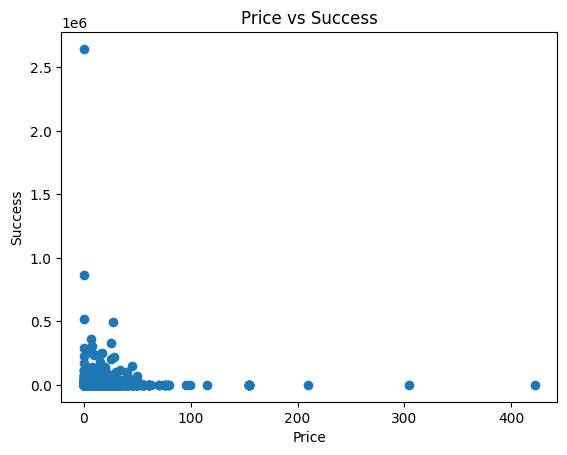

In [10]:
# Success VS Price Plot

plt.scatter(steam["price"], steam["success"])
plt.xlabel("Price")
plt.ylabel("Success")
plt.title("Price vs Success")
plt.show()

In [11]:
steam["success"].describe()

count    2.707500e+04
mean     1.000559e+03
std      1.898872e+04
min      0.000000e+00
25%      6.000000e+00
50%      2.400000e+01
75%      1.260000e+02
max      2.644404e+06
Name: success, dtype: float64

Text(0.5, 1.0, 'Success Distribution')

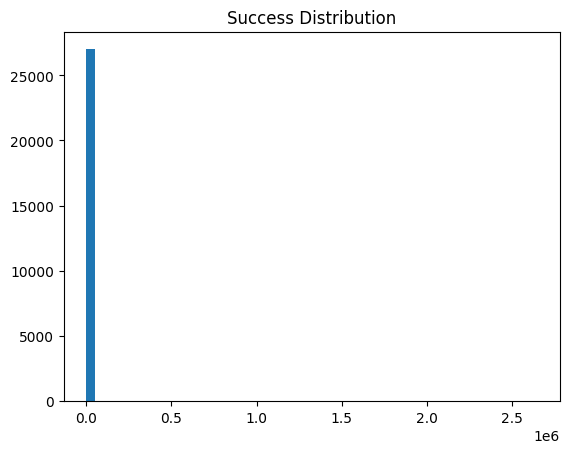

In [12]:
plt.hist(steam["success"], bins=50)
plt.title("Success Distribution")

In [13]:

steam["log_success"] = np.log1p(steam["success"])

Text(0.5, 1.0, 'Log Success Distribution')

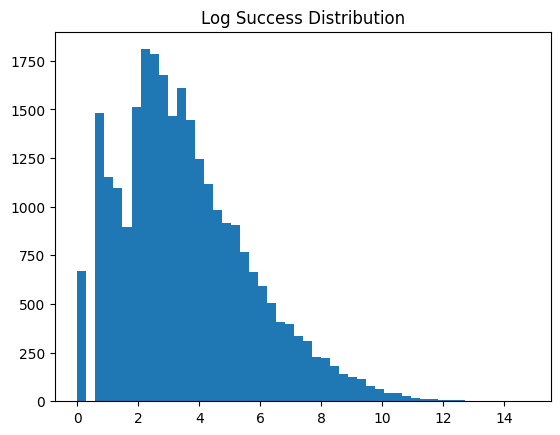

In [14]:
plt.hist(steam["log_success"], bins=50)
plt.title("Log Success Distribution")

The distribution of game success is highly uneven. While most games achieve moderate success, only a small number of titles dominate the platform with very high engagement and visibility.

## Price vs LogSuccess

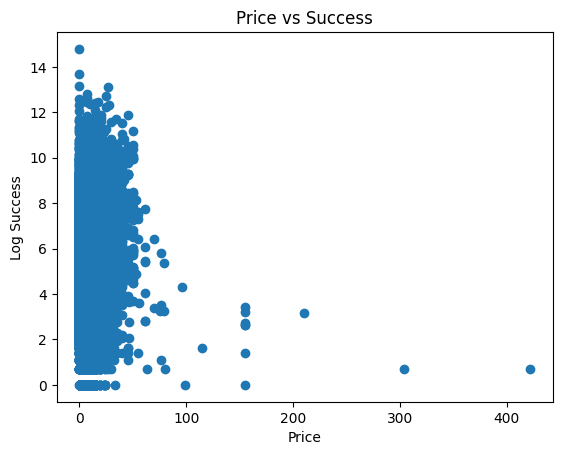

In [15]:

plt.scatter(steam["price"], steam["log_success"])
plt.xlabel("Price")
plt.ylabel("Log Success")
plt.title("Price vs Success")
plt.show()

The majority of Steam games are low-priced or free

The market is heavily concentrated in cheap games

Expensive games are rare and not successful

No linear relationship between price and success, success is spread across prices, but concentrated in cheaper games

## Reviews vs Success

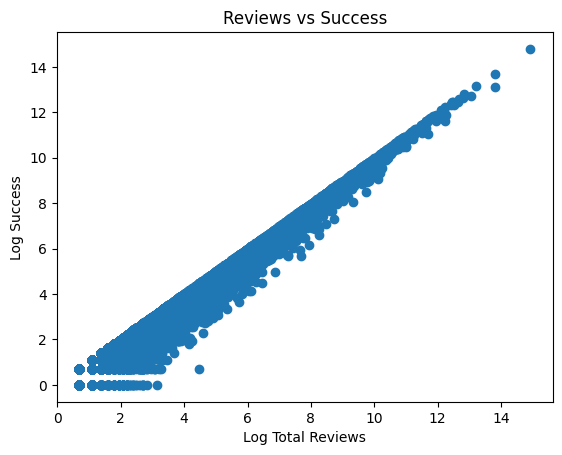

In [16]:
steam["log_reviews"] = np.log1p(steam["total_reviews"])

plt.scatter(steam["log_reviews"], steam["log_success"])
plt.xlabel("Log Total Reviews")
plt.ylabel("Log Success")
plt.title("Reviews vs Success")
plt.show()

There is a strong positive relationship between total reviews and success. This is expected since the success metric includes the number of reviews, highlighting that visibility and player engagement are key drivers of game success.

## Playtime vs Success

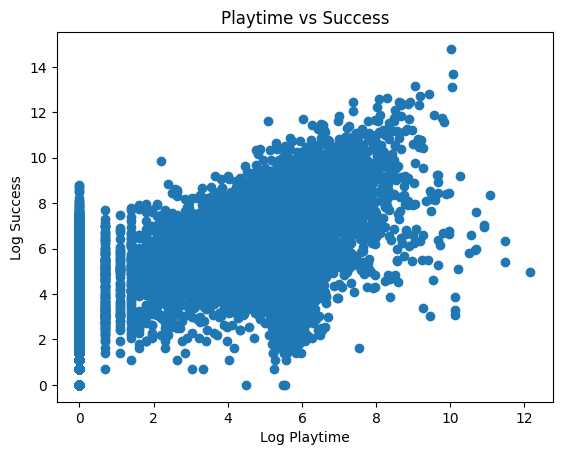

In [17]:
steam["log_playtime"] = np.log1p(steam["average_playtime"])

plt.scatter(steam["log_playtime"], steam["log_success"])
plt.xlabel("Log Playtime")
plt.ylabel("Log Success")
plt.title("Playtime vs Success")
plt.show()

The distribution of success is highly skewed, with most games achieving low to moderate success and a small number of games dominating the platform. A log transformation was applied to better visualize this distribution.

A strong positive relationship was observed between total reviews and success, which is expected since the success metric incorporates the number of reviews. This highlights the importance of visibility and player engagement in driving game performance.

Additionally, games with higher average playtime tend to achieve greater success, suggesting that player retention and engagement are key contributing factors. However, this relationship is less direct than reviews, indicating that multiple factors influence success.

Finally, price does not show a strong correlation with success, suggesting that higher pricing does not necessarily lead to better performance.

------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------

## Correlation Heatmap

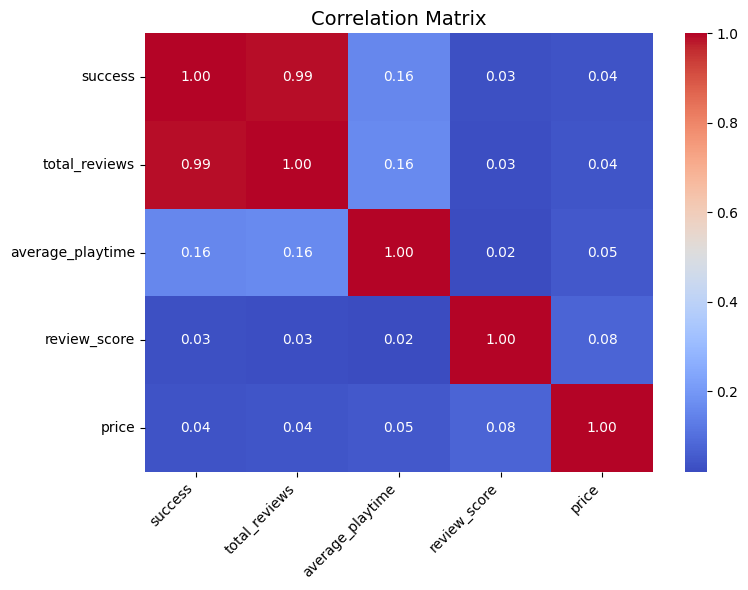

In [78]:
plt.figure(figsize=(8,6))

sns.heatmap(
    steam[[
        "success", 
        "total_reviews", 
        "average_playtime", 
        "review_score", 
        "price"
    ]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix", fontsize=14)

# Rotate axis labels for readability
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

* Success vs Reviews 0.9 correlation is mathematically expected since success formula consists in total_reviews * review_score.



# KPI Definition

To measure game performance, so far Success is define as our main KPI, combining review score (captures customer satisfaction) with total_reviews/review count (This avoids calling a game successful just because it has a high score from only 3-10 reviews.)

In addition to the main KPI, the following supporting KPI's are considered:

* Average Playtime: This is the second main kpi/metric since it covers client engagement, retention and can also increase profit if the game has/could have in-game purchases, even when it's a free-to-play game.

* Price is treated as a strategic business variable rather than a direct KPI. It represents the game’s monetization strategy and is used to explore its impact on success and engagement, the following questions will be explored:

    * Do cheaper games receive more reviews?

    * Is there an optimal price range that maximizes success?

    * Do free-to-play games achieve higher engagement?

    * Are higher-priced games associated with higher or lower review scores? 

--------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------

# Hypothesis

To understand what drives success on Steam, we test the following hypothesis:

* H1: Lower-priced games achieve higher success than high-priced games.
* H2: Games with more reviews tend to achieve higher success.
* H3: Games with higher average playtime tend to be more successful.
* H4: Game success on Steam is highly concentrated among small number of titles.
* H5: There is an optimal price range that maximizes game success.

------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------


### H1: Price vs Success
(Lower-priced games achieve higher success than high-priced games)

In [18]:
steam["price_category"] = "Paid"

steam.loc[steam["price"]== 0, "price_category"] = "Free"

price_bins = [0, 5, 10, 20, 60, 1000]
price_labels = ["Very Cheap", "Cheap", "Lower Mid", "Upper Mid", "Expensive"]

steam.loc[steam["price"] > 0, "price_category"] = pd.cut(
    steam.loc[steam["price"] > 0, "price"],
    bins=price_bins,
    labels=price_labels
)

price_analysis = steam.groupby("price_category")["success"].mean().sort_values(ascending= False)

price_analysis

price_category
Upper Mid     5513.165733
Free          3065.403125
Lower Mid     1853.017754
Cheap          792.838413
Expensive      159.633333
Very Cheap     143.650342
Name: success, dtype: float64

In [19]:
steam.groupby("price_category")["success"].median().sort_values(ascending=False)

price_category
Upper Mid     399.0
Lower Mid      88.0
Free           58.5
Cheap          26.0
Expensive      23.5
Very Cheap     14.0
Name: success, dtype: float64

In [20]:
steam["price_category"].value_counts()

price_category
Very Cheap    13293
Cheap          6300
Lower Mid      3999
Free           2560
Upper Mid       893
Expensive        30
Name: count, dtype: int64

The analysis suggests that success on Steam is highest for games in the upper-mid price range, followed by free-to-play titles. Very cheap and very expensive games show the lowest average success. This indicates that there may be an optimal pricing range rather than a simple pattern where lower prices always lead to better performance.

Advice for companies/publishers:

* Avoid assuming that the lowest possible price will maximize success. Games priced in the upper-mid range appear to balance accessibility and perceived value more effectively, while free-to-play can also be a strong strategy when combined with high engagement.

------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------

### H2: Review vs Success
(Games with higher average reviews tend to be more successful)

In [21]:
steam['review_bucket'] = pd.cut(
    steam["total_reviews"],
    bins=[0, 50, 200, 1000, 10000, 100000],
    labels=["0-50", "50-200", "200+", "1k+", "10k+"]
)

review_analysis= steam.groupby("review_bucket")["success"].mean()

review_analysis

C:\Users\rodri\AppData\Local\Temp\ipykernel_11604\2914874560.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  review_analysis= steam.groupby("review_bucket")["success"].mean()


review_bucket
0-50         11.193771
50-200       73.988084
200+        336.478836
1k+        2472.255288
10k+      21033.228571
Name: success, dtype: float64

Since the "success" metric is calculated as review_score * total reviews,
this KPI behaves roughly as an estimated positive review impact, this means:


The review bucket of 0 to 50 has an average game success of 11.19 (Due to low review count on games with 0 to 50 reviews)
But the review bucket of 10k+ reviews has an average game success of 21033, this is because games with huge review counts are translated to "more success" which is mathematically predicted.

    Example:

    * If game A has 10,000 reviews:

    But only 20% reviews are positive -> The review_score is 0.2.

    So our success metric (review_score * total_reviews) will be: success = 0.2 * 10 000 which equals to 2 000.

    Comparing this 10k+ bin to a game that only has 50 reviews but they're all positive, how can we affirm that the 10k+ reviewed game has higher success than the 50 reviewed game?

    * Both games can be classified as unsuccessful since one lacks popularity and the other lacks positive ratings.

For this reason, review count alone is insufficient to determine true game success. Additional metrics such as playtime are required to better capture player engagement and retention.

------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------

### H3: Playtime vs Success 
(Games with higher average playtime tend to be more successful)

In [22]:
steam["playtime_bucket"] = pd.cut(
    steam["average_playtime"],
    bins= [-1, 0, 60, 300, 1000, 5000, steam["average_playtime"].max()],
    labels= ["0", "1-60min", "1-5hrs", "5-16hrs", "16-83hrs", "83+hrs"]
)

playtime_analysis = steam.groupby("playtime_bucket")["success"].mean().sort_values(ascending=False)

playtime_analysis

C:\Users\rodri\AppData\Local\Temp\ipykernel_11604\2336436708.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  playtime_analysis = steam.groupby("playtime_bucket")["success"].mean().sort_values(ascending=False)


playtime_bucket
83+hrs      77294.811321
16-83hrs    15688.212810
5-16hrs      3937.003610
1-5hrs       1347.782686
1-60min       546.889377
0              61.721980
Name: success, dtype: float64

As predicted, the more the game is played, the more and positive reviews it gets

In [23]:
# Check counts per bucket

steam["playtime_bucket"].value_counts().sort_index()

playtime_bucket
0           20905
1-60min      1365
1-5hrs       2830
5-16hrs      1385
16-83hrs      484
83+hrs        106
Name: count, dtype: int64

20,905 out of 27,075 games = ~77%, have 0 hours of playtime

This means the majority of Steam games fail to achieve meaningful player engagement, so Steam is a highly skewed market.

Out of 27k games, only ~600 games reach a high playtime, higher playtime buckets contain significantly fewer games, indicating that strong engagement is rare but potentially associated with higher success.

In [25]:
# Check average review score with playtime

steam.groupby("playtime_bucket")["review_score"].mean().sort_values(ascending=False)

C:\Users\rodri\AppData\Local\Temp\ipykernel_11604\2315270432.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  steam.groupby("playtime_bucket")["review_score"].mean().sort_values(ascending=False)


playtime_bucket
16-83hrs    0.799012
83+hrs      0.777106
5-16hrs     0.770286
1-5hrs      0.721621
1-60min     0.715650
0           0.707462
Name: review_score, dtype: float64

High-playtime games are not only more successful, but also tend to receive better player ratings, the increase is not massive but its significant (+9%).

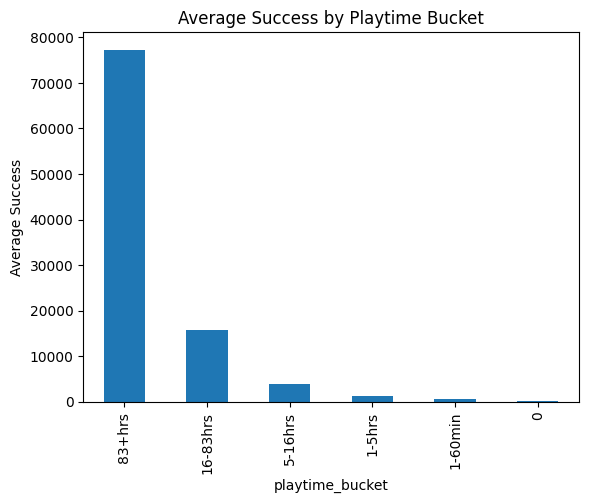

In [26]:
playtime_analysis.plot(kind="bar", title="Average Success by Playtime Bucket")
plt.ylabel("Average Success")
plt.show()

The analysis shows a strong positive relationship between playtime and success. Games with higher average playtime achieve significantly higher success scores, indicating that player engagement and retention are key drivers of performance on Steam. However, high-playtime games represent a relatively small portion of the dataset, suggesting that strong engagement is rare but highly impactful. This highlights the importance of designing games that encourage sustained player interaction.

The results from the third hypothesis suggest that game success on Steam may be driven by a relatively small number of highly engaging titles. However, this conclusion is based on the relationship between playtime and success. To confirm whether success is truly concentrated among a limited number of games, a more direct analysis is required, which is addressed in the fourth hypothesis.

----------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------

### H4: Success Concentration

(Game success on Steam is highly concentrated among small number of titles.)

In [31]:
steam_sorted = steam.sort_values("success", ascending = False)

steam_sorted["cumulative_success"] = steam_sorted["success"].cumsum()

total_success = steam["success"].sum()

steam_sorted["cumulative_percentage"] = steam_sorted["cumulative_success"] / total_success

steam_sorted[["name", "success", "cumulative_percentage"]].head(20)


,name,success,cumulative_percentage
25,Counter-Strike: Global Offensive,2644404.0,0.097615
22,Dota 2,863507.0,0.129490
19,Team Fortress 2,515879.0,0.148533
12836,PLAYERUNKNOWN'S BATTLEGROUNDS,496184.0,0.166850
121,Garry's Mod,363721.0,0.180276
2478,Grand Theft Auto V,329061.0,0.192423
1467,PAYDAY 2,308657.0,0.203816
3362,Unturned,292574.0,0.214616
1120,Terraria,255600.0,0.224052
21,Left 4 Dead 2,251789.0,0.233346


This Top 20 games list are ~0.07% of all Steam games (20 games out of 27k) yet they generate 30.7% of total success.

In [34]:
top_games = steam_sorted[steam_sorted["cumulative_percentage"] <= 0.8]
len(top_games), len(top_games) / len(steam)

(736, 0.027183748845798706)

The analysis shows that game success on Steam is highly concentrated among a very small number of titles. Approximately 2.7% of games account for 80% of total success, indicating a strong winner-takes-most dynamic. Additionally, the top 20 games alone generate over 30% of total success, despite representing less than 0.1% of all titles. This highlights the extreme inequality in game performance on the platform, where only a small fraction of games achieve significant visibility and impact.

This concentration suggests that achieving high success on Steam requires reaching the top-performing segment, as the majority of games receive minimal attention and engagement.

To complete our business recommendations we analyze the optimal price range with Hypothesis 5

--------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------

### H5: Optimal Price range in Steam games

(There is an optimal price range that maximizes game success)

In [41]:
# For each price category, what is the average performance across all key metrics?

steam.groupby("price_category")[[
    "success", 
    "total_reviews", 
    "review_score", 
    "average_playtime"
]].mean()

,success,total_reviews,review_score,average_playtime
price_category,,,,
Cheap,792.838413,894.742222,0.745003,88.038730
Expensive,159.633333,185.933333,0.754777,74.033333
Free,3065.403125,3695.566797,0.719060,463.128516
Lower Mid,1853.017754,2161.719430,0.757227,193.546387
Upper Mid,5513.165733,7487.312430,0.741594,851.816349
Very Cheap,143.650342,178.266080,0.684356,58.589558


This Hypothesis shows us the full performance profile on each price category.

The analysis indicates that games priced in the upper-mid range achieve the highest overall performance across all key metrics, including success, popularity, and player engagement. While free-to-play games also demonstrate strong engagement and reach, they tend to have slightly lower review scores. In contrast, very cheap and expensive games show significantly lower performance, suggesting that both underpricing and overpricing can negatively impact success. These findings support the existence of an optimal price range that balances accessibility, perceived value, and player engagement.

Developers should aim to position their games within the upper-mid price range, as it appears to offer the best balance between attracting players, maintaining engagement, and achieving strong overall performance.

----------------------------------------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------------------------------------

## Market and Business Insights

After analyzing game performance from price, success and playtime we now look at Steam games as a market and business, we want to answer questions like:

* What kind of games win?
* Who makes them?
* Where should Steam invest and why?

For this we come up with two new hypothesis:

* H6: Which genre of games perform best?
* H7: Who creates successful games?
---------------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------------

### H6: Genre Analysis

(Which genre of games perform best)

In [42]:
# Since genre column has multiple genres in a row, first we split the genres.

genres_expanded = steam.assign(
    genre=steam["genres"].str.split(";")
).explode("genre")

In [48]:
genre_analysis = genres_expanded.groupby("genre")[[
    "success",
    "total_reviews",
    "review_score",
    "average_playtime"
]].mean().sort_values(by="success", ascending = False)

genre_analysis.head(20)

,success,total_reviews,review_score,average_playtime
genre,,,,
Free to Play,4346.627347,5247.443662,0.699454,554.437793
Massively Multiplayer,3468.112033,5352.200553,0.611893,725.484094
Action,1581.931446,1938.693943,0.709888,144.016634
RPG,1346.576896,1624.963582,0.716261,276.985850
Animation & Modeling,1126.949367,1199.113924,0.738733,88.139241
Design & Illustration,880.712644,932.873563,0.752982,112.229885
Adventure,869.724083,1102.774821,0.713753,151.656699
Strategy,863.992567,1044.205641,0.692914,193.130170
Nudity,822.218045,1034.266917,0.709080,99.973684


Free to play, multiplayer and action genres on top 3

In [54]:
# Lets have a look at genres without splitting them:

steam.groupby("genres")["success"].mean().sort_values(ascending=False).head(20)

genres
Action;Free to Play;Strategy                                                          108938.000000
Action;Adventure;Massively Multiplayer                                                102626.833333
Action;Free to Play                                                                    93925.475000
Action;Free to Play;Indie;Massively Multiplayer;RPG;Simulation                         80360.000000
Action;Adventure;Free to Play;Massively Multiplayer                                    55847.500000
Nudity;Violent;Gore;Action;Adventure;Indie;RPG;Simulation;Strategy;Early Access        30363.500000
Action;Adventure;Indie;Massively Multiplayer;RPG                                       29585.846154
Adventure;Casual;Free to Play;Massively Multiplayer;Simulation;Sports;Early Access     25818.000000
Action;Free to Play;Massively Multiplayer;Simulation                                   25491.500000
Massively Multiplayer;RPG                                                              21763.

### H6 Visualizations

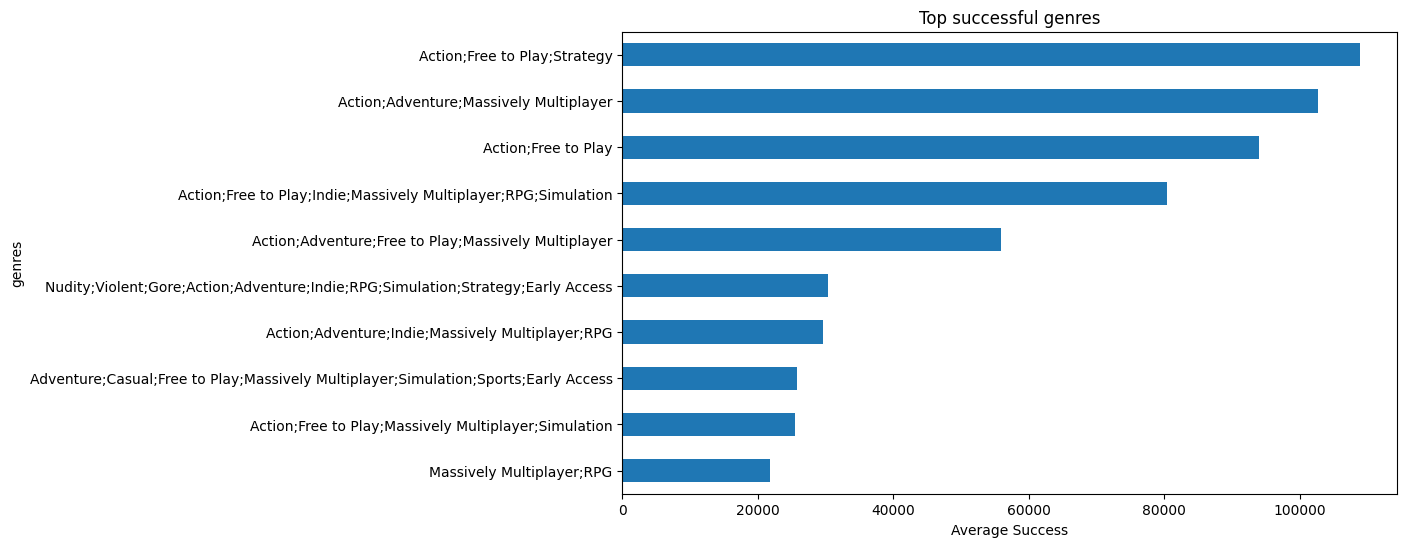

In [63]:
# Top genres success(reviews) without splitting them

top_genres_combo = steam.groupby("genres")["success"] \
    .mean() \
    .sort_values(ascending=False) \
    .head(10) # Only top 10 genres
    
top_genres_combo.sort_values().plot(kind="barh", figsize=(10,6))

plt.title("Top successful genres")
plt.xlabel("Average Success")
plt.ylabel

plt.show()

While Free-to-Play and multiplayer games appear among the highest-performing categories, this does not imply that monetization model alone determines success. Free-to-Play represents a pricing strategy rather than a game genre. The results show that high-performing games typically combine Free-to-Play with engaging genres such as Action, RPG and Massively Multiplayer. This suggests that success is driven by the interaction between monetization strategy and gameplay design, rather than by pricing alone as concluded in previous hypothesis.

Steam should promote games that combine strong engagement mechanics (such as multiplayer and action/rpg systems) with effective monetization strategies(Free or upper mid pricing).

--------------------------------------------------------------------------------
--------------------------------------------------------------------------------

### H7: Publisher performance

(Who creates successful games)

In [71]:
steam["publisher"].value_counts().describe()

count    14353.000000
mean         1.885390
std          4.697589
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        212.000000
Name: count, dtype: float64

~14k publishers out of 27k games which gives a ratio of about 2 games per publisher, this means many publishers have published only 1 or 2 game in Steam which also indicates that we have few top publishers that might dominate the platform (as seen before in H4)

In [ ]:
dev_counts = steam["developer"].value_counts()

# Keeping only developers with at least 5 games
valid_devs = dev_counts[dev_counts >= 5].index

steam_dev = steam[steam["developer"].isin(valid_devs)]

In [75]:
dev_analysis = steam_dev.groupby("developer").agg({
    "success": "mean",
    "total_reviews": "mean",
    "average_playtime": "mean",
    "review_score": "mean",
    "appid": "count"
}).rename(columns={"appid":"num_games"}).sort_values(by="success", ascending= False)

dev_analysis.head(10)

,success,total_reviews,average_playtime,review_score,num_games
developer,,,,,
Valve,86672.115385,95159.884615,2663.538462,0.890779,26
Bethesda Game Studios,47296.900000,56177.400000,2001.800000,0.827713,10
Tripwire Interactive,28663.000000,31387.200000,1059.600000,0.851455,5
Klei Entertainment,19098.000000,20019.571429,621.714286,0.895675,7
Ubisoft Montreal,19070.157895,23274.473684,1027.368421,0.785946,19
Obsidian Entertainment,18309.142857,19555.714286,1331.428571,0.844867,7
SCS Software,17348.333333,18161.250000,648.500000,0.764742,12
Bohemia Interactive,15939.812500,22225.187500,2260.187500,0.657844,16
Avalanche Studios,14870.666667,18750.166667,735.166667,0.740329,6


The most successful developers are not one-hit wonders but studios that consistently produce high-performing games across multiple titles.

The analysis identifies a group of developers that consistently produce highly successful games on Steam. Studios such as Valve, Bethesda Game Studios, and Ubisoft Montreal achieve strong performance across multiple titles, indicating sustained success rather than isolated hits. These developers also exhibit high levels of player engagement and strong review scores, suggesting that both retention and player satisfaction contribute to their success. This reinforces the idea that successful games result from a combination of quality, engagement, and scale.

Steam should prioritize partnerships and promotional visibility for developers that consistently deliver high-performing and engaging games. Supporting these studios can drive sustained platform growth and maximize user engagement.